In [2]:
# 1. 下载开源中文字体 (SimHei 黑体) 到 Colab 环境
!wget -q -O SimHei.ttf "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 2. 将下载的字体动态注册到 matplotlib
fm.fontManager.addfont('SimHei.ttf')

# 3. 强制覆盖全局字体设置，并解决负号显示问题
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。")

✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。


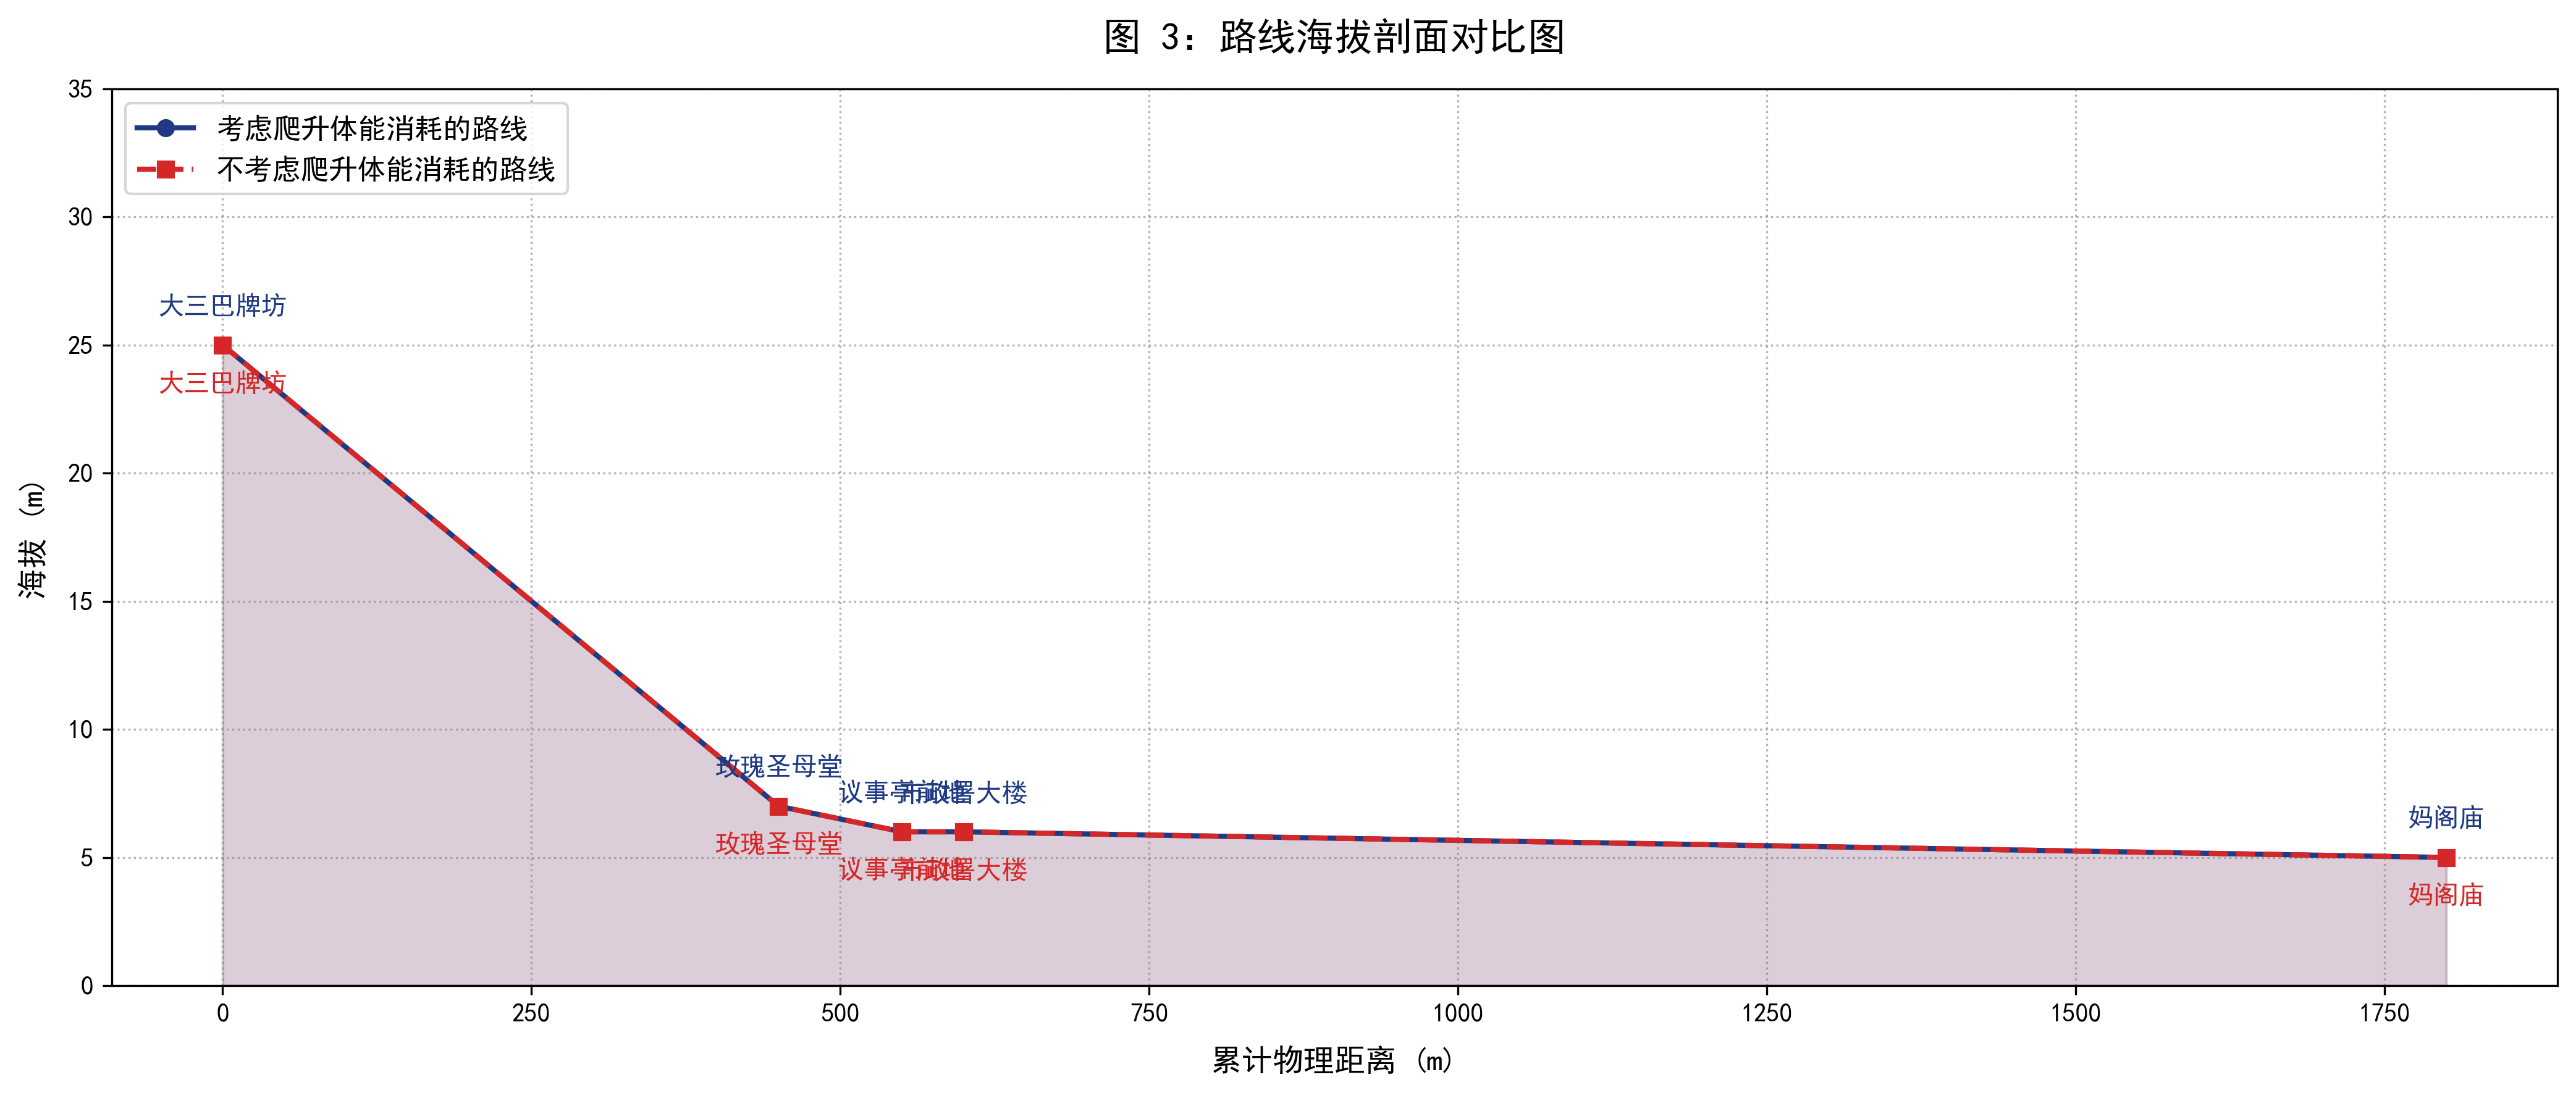

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# 确保图表正常显示，设置全局字体防止中文变成方块
%matplotlib inline
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

def plot_elevation_comparison(file1, file2):
    # 读取数据
    df1 = pd.read_csv(file1) # 考虑爬升体能消耗的路线 (export1)
    df2 = pd.read_csv(file2) # 不考虑爬升体能消耗的路线 (export2)

    fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

    # 绘制路线 1：考虑体能消耗
    ax.plot(df1['Cumulative_Distance_m'], df1['Elevation_m'],
            label='考虑爬升体能消耗的路线', color='#1F3A82', marker='o', lw=2, markersize=6)
    ax.fill_between(df1['Cumulative_Distance_m'], df1['Elevation_m'], color='#1F3A82', alpha=0.15)

    # 为路线 1 标注节点
    for i, row in df1.iterrows():
        ax.annotate(row['Point_Index'],
                    (row['Cumulative_Distance_m'], row['Elevation_m']),
                    textcoords="offset points", xytext=(0, 10), ha='center',
                    color='#1F3A82', fontweight='bold', fontsize=10)

    # 绘制路线 2：不考虑体能消耗
    ax.plot(df2['Cumulative_Distance_m'], df2['Elevation_m'],
            label='不考虑爬升体能消耗的路线', color='#D62728', marker='s', lw=2, linestyle='--', markersize=6)
    ax.fill_between(df2['Cumulative_Distance_m'], df2['Elevation_m'], color='#D62728', alpha=0.1)

    # 为路线 2 标注节点
    for i, row in df2.iterrows():
        ax.annotate(row['Point_Index'],
                    (row['Cumulative_Distance_m'], row['Elevation_m']),
                    textcoords="offset points", xytext=(0, -15), ha='center',
                    color='#D62728', fontweight='bold', fontsize=10)

    # 图表装饰与排版
    ax.set_title('图 3：路线海拔剖面对比图', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('累计物理距离 (m)', fontsize=12, labelpad=8)
    ax.set_ylabel('海拔 (m)', fontsize=12, labelpad=8)

    # 图例设置
    ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=False)

    # 网格与边框
    ax.grid(True, linestyle=':', color='gray', alpha=0.6)
    for spine in ax.spines.values():
        spine.set_color('black')

    fig.tight_layout()
    plt.show()

# 调用函数生成对比图
plot_elevation_comparison('df_path_step.csv', 'df_path_step.csv2')

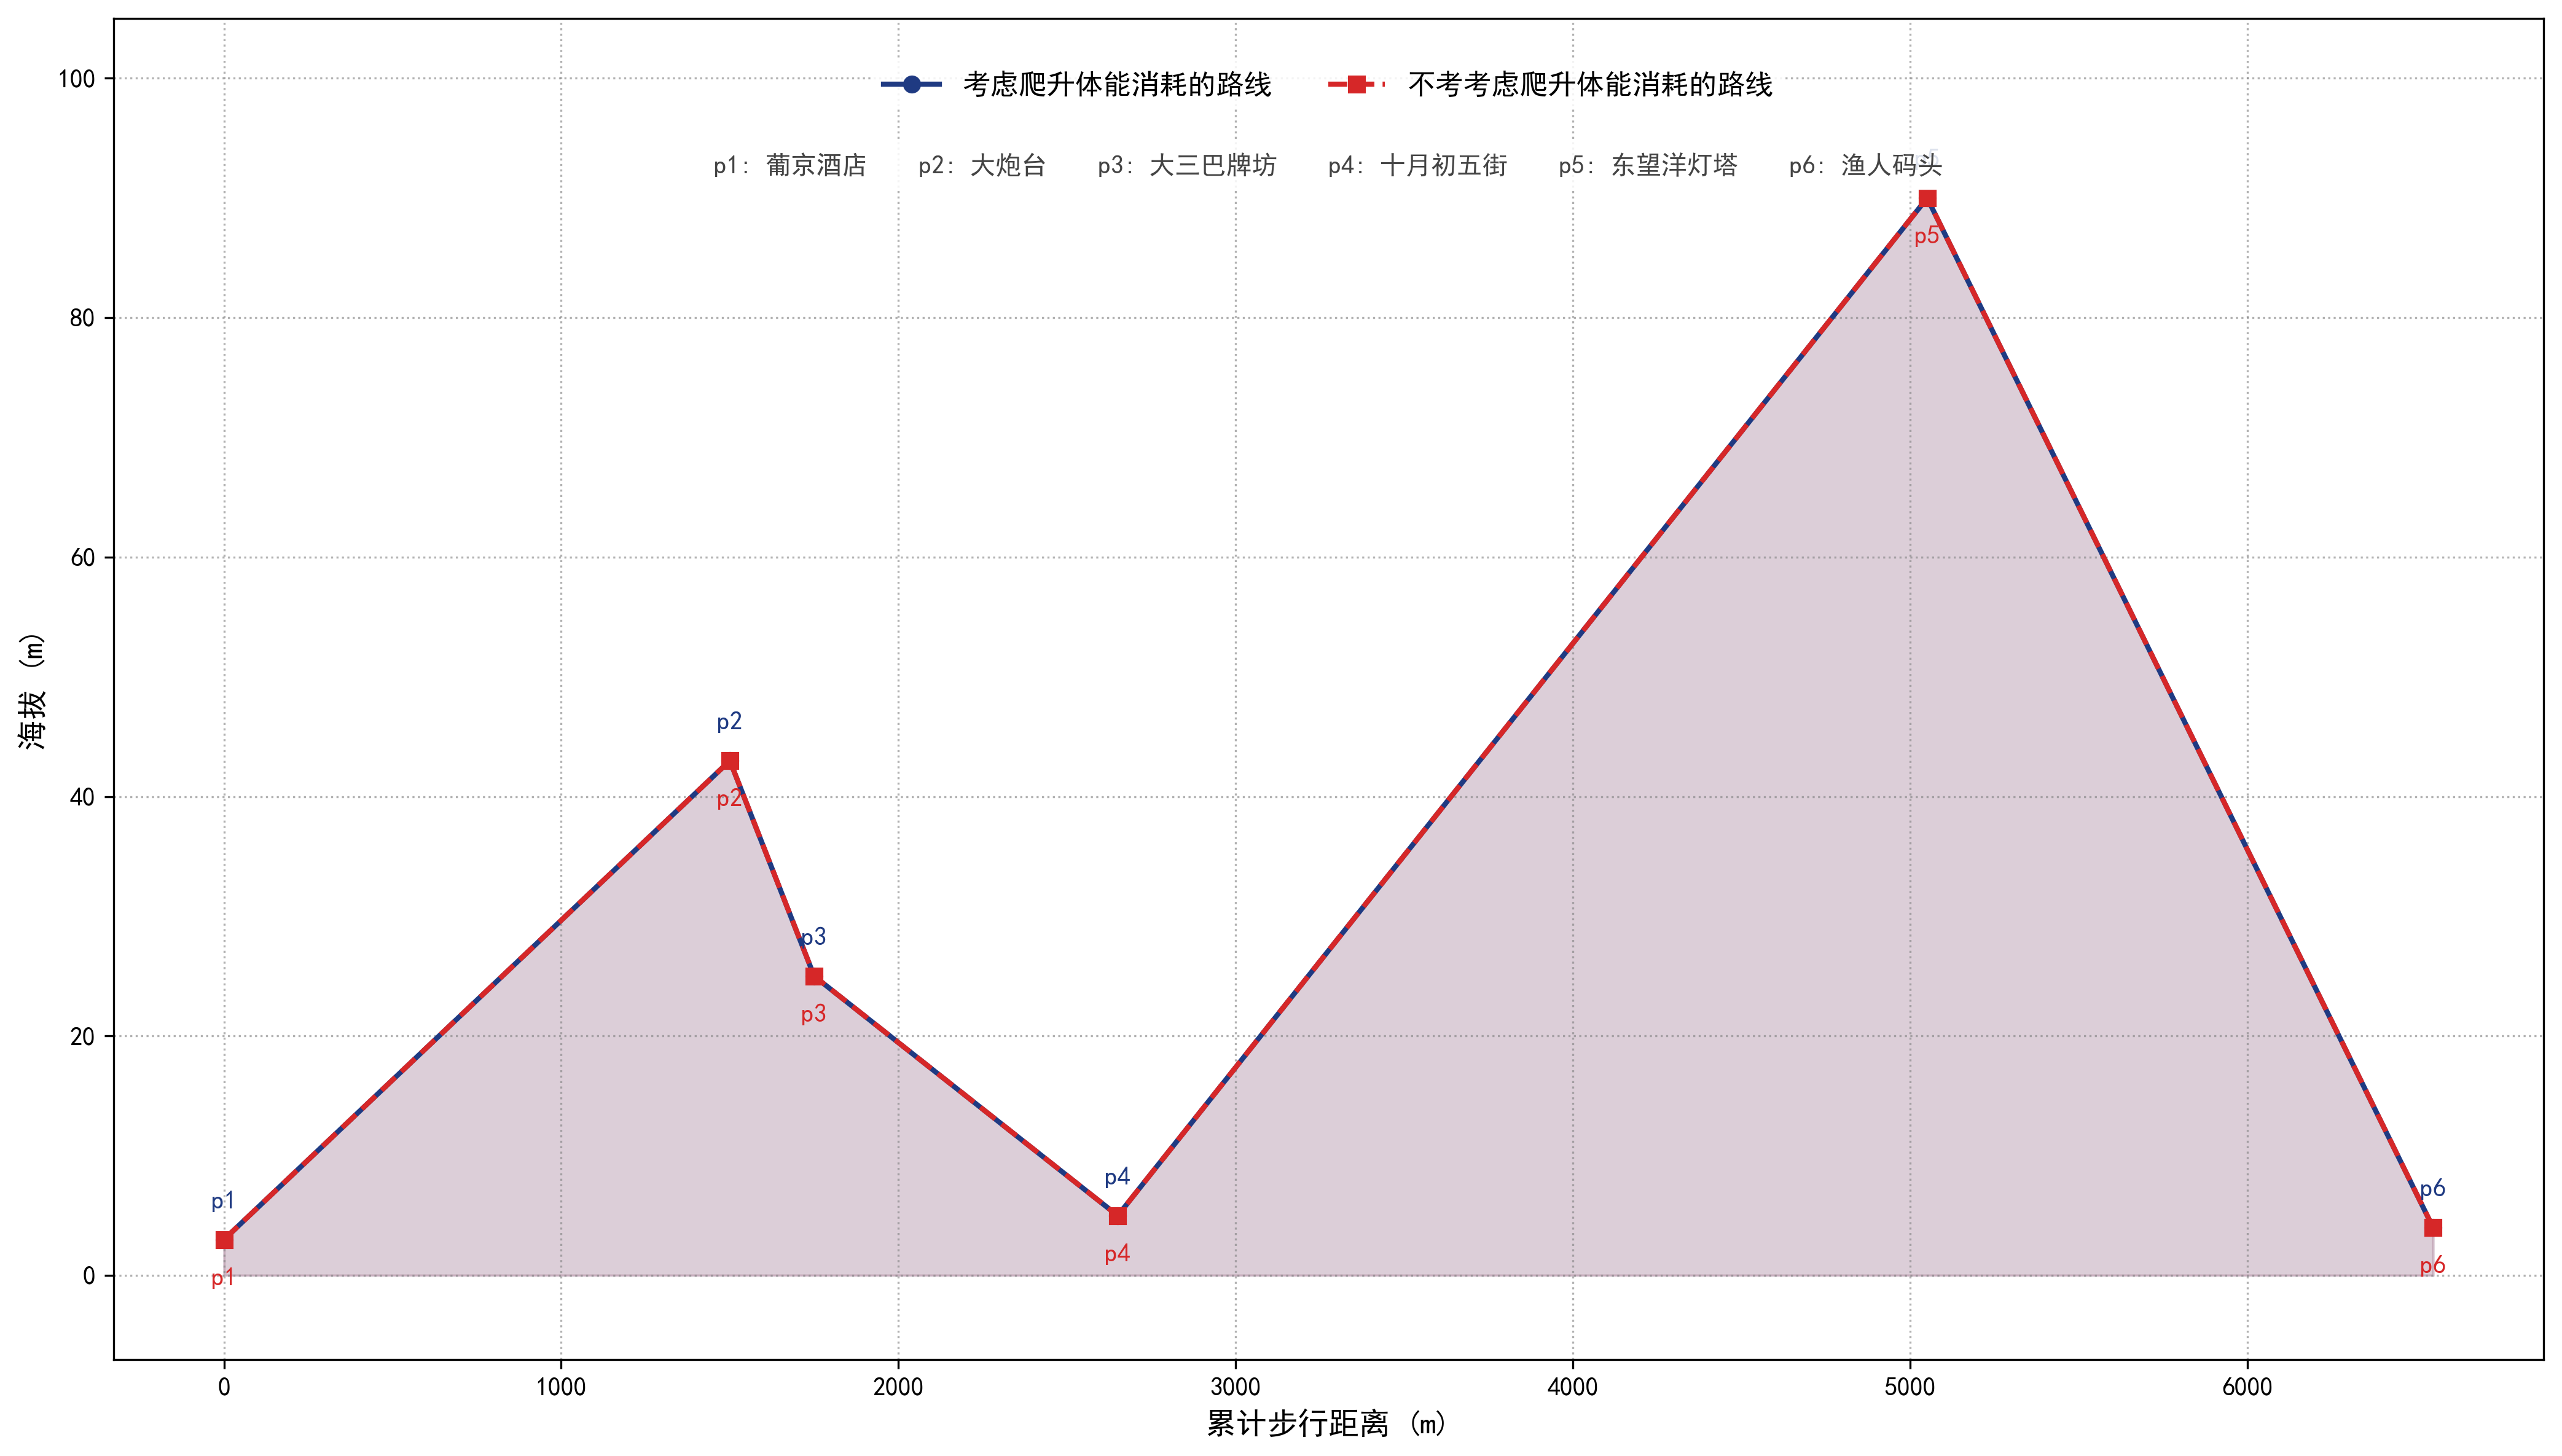

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import textwrap

# 确保图表正常显示
%matplotlib inline
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

def plot_elevation_comparison(file1, file2):
    # 1. 读取数据
    df1 = pd.read_csv(file1)
    df2 = pd.read_csv(file2)

    # 计算累计物理距离
    df1['Cumulative_Distance_m'] = df1['平面步行距离'].cumsum()
    df2['Cumulative_Distance_m'] = df2['平面步行距离'].cumsum()

    # 2. 生成景点编号映射 (p1, p2...)
    unique_pois = []
    for name in df1['POI_Name']:
        if name not in unique_pois:
            unique_pois.append(name)
    for name in df2['POI_Name']:
        if name not in unique_pois:
            unique_pois.append(name)
    poi_map = {name: f"p{i+1}" for i, name in enumerate(unique_pois)}

    # 3. 创建画布
    # 增加高度 (8) 为底部留出更多空间
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

    # 绘制路线 1
    line1, = ax.plot(df1['Cumulative_Distance_m'], df1['Elevation'],
                     label='考虑爬升体能消耗的路线', color='#1F3A82', marker='o', lw=2, markersize=6)
    ax.fill_between(df1['Cumulative_Distance_m'], df1['Elevation'], color='#1F3A82', alpha=0.15)

    for i, row in df1.iterrows():
        ax.annotate(poi_map[row['POI_Name']], (row['Cumulative_Distance_m'], row['Elevation']),
                    textcoords="offset points", xytext=(0, 12), ha='center',
                    color='#1F3A82', fontweight='bold', fontsize=10)

    # 绘制路线 2
    line2, = ax.plot(df2['Cumulative_Distance_m'], df2['Elevation'],
                     label='不考考虑爬升体能消耗的路线', color='#D62728', marker='s', lw=2, linestyle='--', markersize=6)
    ax.fill_between(df2['Cumulative_Distance_m'], df2['Elevation'], color='#D62728', alpha=0.1)

    for i, row in df2.iterrows():
        ax.annotate(poi_map[row['POI_Name']], (row['Cumulative_Distance_m'], row['Elevation']),
                    textcoords="offset points", xytext=(0, -18), ha='center',
                    color='#D62728', fontweight='bold', fontsize=10)

    # 图表装饰
    #ax.set_title('图 3：路线海拔剖面对比图', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('累计步行距离 (m)', fontsize=12)
    ax.set_ylabel('海拔 (m)', fontsize=12)
    ax.grid(True, linestyle=':', color='gray', alpha=0.6)

    # 动态扩展Y轴
    y_max = max(df1['Elevation'].max(), df2['Elevation'].max())
    y_min = min(df1['Elevation'].min(), df2['Elevation'].min())
    ax.set_ylim(y_min - 10, y_max + 15)

# --- 核心修改：图例和文字都移到上方 ---

    # 1. 图例移到坐标轴内部的顶部居中
    # 开启 frameon=True 并设置半透明白底，防止被后面的网格和折线遮挡
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98),
              ncol=2, frameon=True, facecolor='white', edgecolor='none', framealpha=0.85, fontsize=11)

    # 2. 生成编号对照文本
    mapping_items = [f"{v}: {k}" for k, v in poi_map.items()]
    mapping_str = "    ".join(mapping_items)
    wrapped_mapping_str = textwrap.fill(mapping_str, width=95)

    # 3. 将文本移动到图例的正下方 (Y 坐标设为 0.90)
    ax.text(0.5, 0.90, wrapped_mapping_str, transform=ax.transAxes,
            ha='center', va='top', fontsize=10, color='#444444', linespacing=1.6,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="none", alpha=0.85))

    # 4. 使用自动紧凑布局，不需要再给底部留白
    plt.tight_layout()

    plt.show()

# 执行
plot_elevation_comparison('df_path_step.csv', 'df_path_step2.csv')


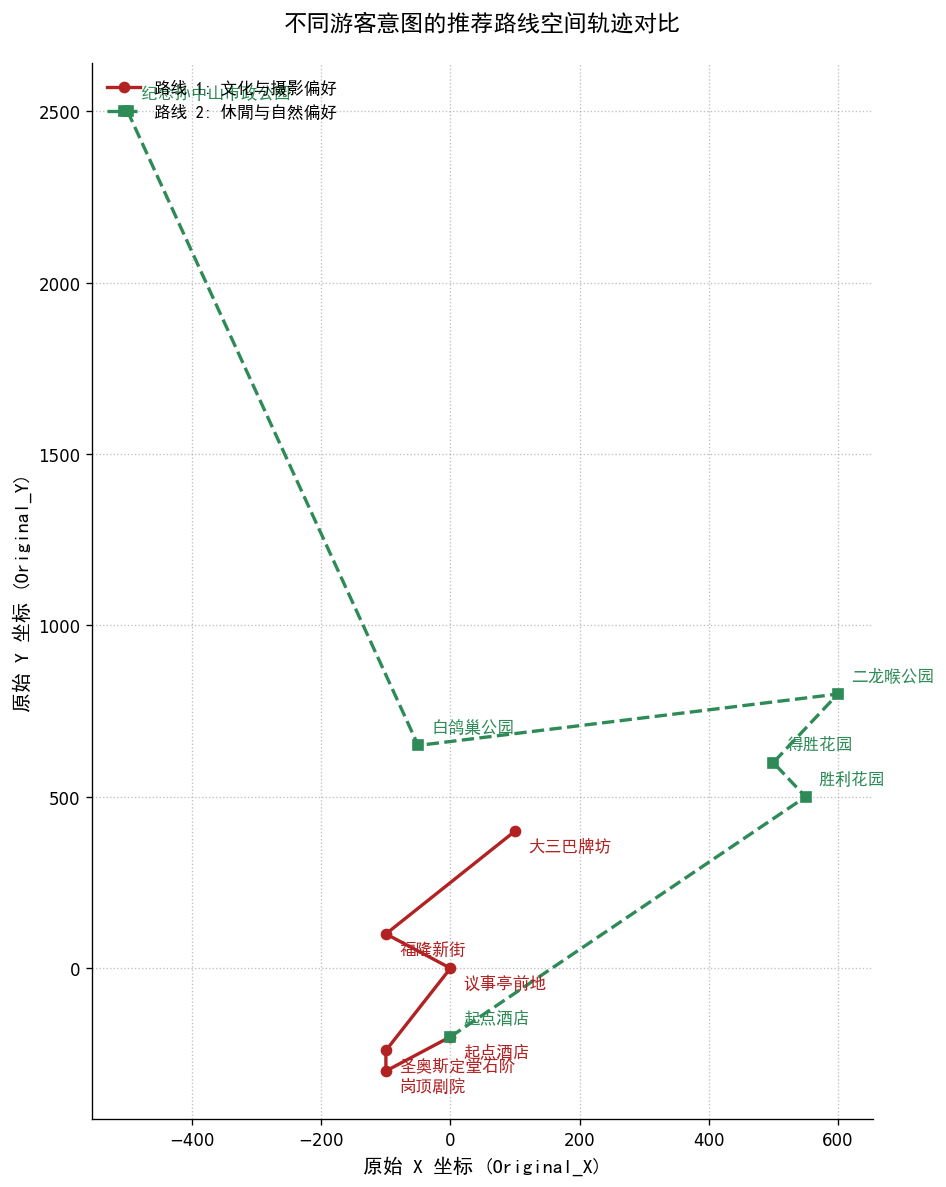

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 自动下载中文字体（解决 Colab 中文显示为方块的问题）
font_path = 'SimHei.ttf'
if not os.path.exists(font_path):
    !wget -q -O SimHei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf

# 加载字体属性
my_font = fm.FontProperties(fname=font_path)

# 2. 读取 CSV 数据
df1 = pd.read_csv('plot_data_export1.csv')
df2 = pd.read_csv('plot_data_export2.csv')

# 3. 创建画布 (学术简洁风格)
fig, ax = plt.subplots(figsize=(8, 10), dpi=120)

# 移除顶部和右侧的边框线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. 绘制路线 1 (文化与摄影类)
# 使用实线和圆形标记，砖红色代表人文建筑
ax.plot(df1['Original_X'], df1['Original_Y'],
        marker='o', linestyle='-', color='#B22222', linewidth=2, markersize=6,
        label='路线 1: 文化与摄影偏好')

for idx, row in df1.iterrows():
    ax.annotate(row['Location_Name'],
                (row['Original_X'], row['Original_Y']),
                xytext=(8, -12), textcoords='offset points', # 向右下方偏移
                fontproperties=my_font, fontsize=10, color='#B22222')

# 5. 绘制路线 2 (休闲与自然类)
# 使用虚线和方形标记，海绿色代表自然公园
ax.plot(df2['Original_X'], df2['Original_Y'],
        marker='s', linestyle='--', color='#2E8B57', linewidth=2, markersize=6,
        label='路线 2: 休閒与自然偏好')

for idx, row in df2.iterrows():
    ax.annotate(row['Location_Name'],
                (row['Original_X'], row['Original_Y']),
                xytext=(8, 8), textcoords='offset points',  # 向右上方偏移，避免与路线1起点重叠
                fontproperties=my_font, fontsize=10, color='#2E8B57')

# 6. 图表细节与标签设置
ax.set_xlabel('原始 X 坐标 (Original_X)', fontproperties=my_font, fontsize=12)
ax.set_ylabel('原始 Y 坐标 (Original_Y)', fontproperties=my_font, fontsize=12)
ax.set_title('不同游客意图的推荐路线空间轨迹对比', fontproperties=my_font, fontsize=14, pad=20)

# 图例设置 (去除图例外框线以保持整洁)
ax.legend(prop=my_font, loc='upper left', frameon=False, fontsize=11)

# 添加极简网格线作为背景参考
ax.grid(True, linestyle=':', alpha=0.5, color='gray')

# 自动调整布局并展示
plt.tight_layout()
plt.show()

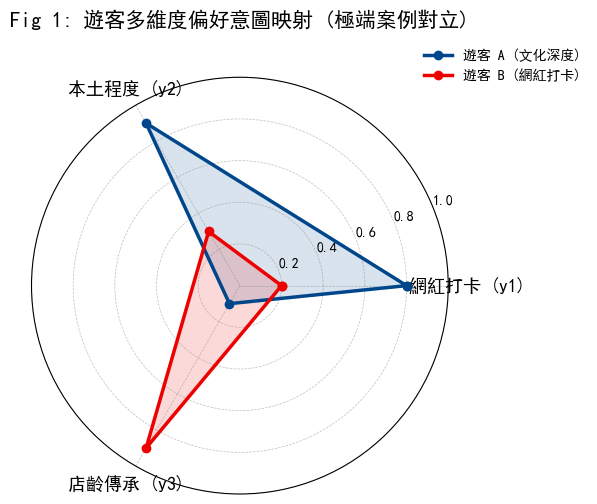

In [ ]:
# ==========================================
# 儲存格 1: 環境配置與多維度偏好雷達圖
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import os
import urllib.request

# 1. 解決 Colab 中文顯示問題：自動下載並設定字型
font_url = "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"
font_path = "SimHei.ttf"

if not os.path.exists(font_path):
    print("正在下載中文字型...")
    urllib.request.urlretrieve(font_url, font_path)
    print("字型下載完成！")

# 載入字型
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
my_font = fm.FontProperties(fname=font_path)

# 2. 參數初始化 (依照您的模型設計)
# 維度: [網紅打卡 (y1), 本土程度 (y2), 店齡傳承 (y3)]
labels = np.array(['網紅打卡 (y1)', '本土程度 (y2)', '店齡傳承 (y3)'])
U_A = np.array([0.8, 0.9, 0.1])  # 遊客 A (文化深度)
U_B = np.array([0.2, 0.3, 0.9])  # 遊客 B (網紅打卡)

# 閉合雷達圖邊界
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
U_A_closed = np.concatenate((U_A, [U_A[0]]))
U_B_closed = np.concatenate((U_B, [U_B[0]]))
angles_closed = np.concatenate((angles, [angles[0]]))

# 3. 繪圖設定 (SCI 配色風格)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
color_A = '#00468B'  # NPG Blue
color_B = '#ED0000'  # NPG Red

# 繪製遊客 A
ax.plot(angles_closed, U_A_closed, 'o-', linewidth=2.5, color=color_A, label='遊客 A (文化深度)')
ax.fill(angles_closed, U_A_closed, alpha=0.15, color=color_A)

# 繪製遊客 B
ax.plot(angles_closed, U_B_closed, 'o-', linewidth=2.5, color=color_B, label='遊客 B (網紅打卡)')
ax.fill(angles_closed, U_B_closed, alpha=0.15, color=color_B)

# 標籤與格式設定
ax.set_thetagrids(angles * 180 / np.pi, labels, fontproperties=my_font, fontsize=13)
ax.set_ylim(0, 1)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# 圖例與標題
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), prop=my_font, fontsize=11, frameon=False)
plt.title('Fig 1: 遊客多維度偏好意圖映射 (極端案例對立)', fontproperties=my_font, fontsize=15, y=1.1, fontweight='bold')

plt.tight_layout()
plt.show()